# Exploratory Data Analysis (EDA) — EcoHome a.s.

## 1. Pravidla práce

- EDA není jen generování grafů, ale systematické porozumění datům.
- Každý krok analýzy by měl mít vazbu na cíl projektu, KPI nebo analytickou otázku.
- Nestačí ukázat výstup; je potřeba stručně interpretovat, co z něj plyne a co z něj naopak tvrdit nelze.
- Pokud data obsahují problém, omezení nebo nekonzistenci, uveďte to explicitně.
- AI používejte jako pomocníka pro návrh postupu, struktury a kódu, ne jako zdroj hotových závěrů.
- Všechny závěry musí být dohledatelné a ověřitelné přímo z dat a kroků v notebooku.
- Pokud něco nelze zjistit spolehlivě, napište to otevřeně a nepřehánějte interpretaci.

> **Důležité:**  
> Pište komentáře k datům, k výstupům.  
> Celý výstup by měl sloužit jako prezentace někomu jinému.

## 2. Kontext analýzy

- **Název projektu:** EcoHome a.s. — Datová platforma pro optimalizaci energetické spotřeby domácností
- **Stručný popis domény:** EcoHome a.s. je fiktivní firma poskytující chytré řízení energií v domácnostech. Kombinuje meteorologická data (Open-Meteo API) s daty z IoT smart meterů pro optimalizaci spotřeby a maximalizaci využití solární energie.
- **Cíl této analýzy:** Prozkoumat vztah mezi počasím, solární výrobou a spotřebou elektřiny. Identifikovat vzorce závislosti na síti, náklady ve špičkové hodiny a kvalitu senzorových dat.
- **Hlavní analytické otázky:**
  1. Jak moc jsou domácnosti závislé na síťové elektřině vs. vlastní solární výrobě?
  2. Jaké jsou náklady ve večerní špičce (18:00–21:00) a jak se liší podle sezóny?
  3. Jak spolehlivá jsou data ze senzorů (výpadky, šum)?
- **KPI:**
  - **GDR (Grid Dependency Ratio):** Podíl síťové elektřiny na celkové spotřebě (`1 - solarni_vyroba / spotreba`). Jednotka: %, měsíční periodicita.
  - **PLC (Peak Load Cost):** Simulovaný náklad za spotřebu ve špičce 18:00–21:00 (`sum(spotreba_18_21) * cena_kWh`). Jednotka: CZK, denní/měsíční.
  - **DQS (Data Quality Score):** Podíl platných (ne-null, ne-outlier) záznamů z celkového počtu. Jednotka: %, týdenní.
- **Proč jsou vybraná data relevantní:** Meteorologická data ovlivňují solární výrobu, smart meter data zachycují reálnou spotřebu — jejich propojení umožňuje měřit všechna tři KPI.

## 3. Načtení dat a technická příprava

> **Účel:** Načíst surová data ze dvou zdrojů (CSV + Parquet), integrovat je do DuckDB a připravit analytický pohled `v_net_load` pro další analýzu.

In [26]:
# === Import knihoven a kontrola prostředí ===

import importlib.util  # modul pro dynamickou kontrolu dostupnosti balíčků
import subprocess       # modul pro spouštění systémových příkazů (pip install)
import sys              # přístup k systémovým informacím (cesta k Pythonu)

def ensure_package(package_name: str, import_name: str | None = None) -> None:
    """Zkontroluje, zda je balíček nainstalovaný. Pokud ne, doinstaluje ho."""
    module_name = import_name or package_name  # název modulu pro import (může se lišit od pip názvu)
    if importlib.util.find_spec(module_name) is None:  # pokud modul není dostupný
        print(f"Balíček '{package_name}' není nainstalovaný. Probíhá instalace...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])  # instalace přes pip
    else:
        print(f"Balíček '{package_name}' je dostupný.")  # potvrzení dostupnosti

# Zajistíme dostupnost všech potřebných knihoven
ensure_package("duckdb")      # analytická in-process databáze
ensure_package("pandas")      # práce s tabulkovými daty (DataFrame)
ensure_package("matplotlib")  # tvorba grafů
ensure_package("seaborn")     # statistické vizualizace nad matplotlib

Balíček 'duckdb' je dostupný.
Balíček 'pandas' je dostupný.
Balíček 'matplotlib' je dostupný.
Balíček 'seaborn' je dostupný.


In [27]:
# === Importy hlavních knihoven ===

import duckdb                       # DuckDB — analytická SQL databáze
import pandas as pd                 # Pandas — manipulace s tabulkovými daty
import matplotlib.pyplot as plt     # Matplotlib — tvorba grafů
import seaborn as sns               # Seaborn — pokročilé statistické vizualizace
import warnings                     # modul pro potlačení varování
from pathlib import Path            # objektová práce se souborovými cestami

# Nastavení zobrazení v Pandas — zobrazíme více sloupců pro přehlednost
pd.set_option("display.max_columns", 200)  # max počet zobrazených sloupců
pd.set_option("display.width", 140)         # šířka výstupu v znacích

# Nastavení vizuálního stylu grafů
sns.set_theme(style="whitegrid", palette="muted")  # čistý styl s mřížkou
plt.rcParams["figure.figsize"] = (12, 6)           # výchozí velikost grafů
plt.rcParams["figure.dpi"] = 100                    # rozlišení grafů

# Potlačení nepodstatných varování pro čistší výstup
warnings.filterwarnings("ignore", category=FutureWarning)

In [28]:
# === Připojení k DuckDB a načtení dat ===

DB_PATH = "projekt.duckdb"  # cesta k databázovému souboru DuckDB
con = duckdb.connect(DB_PATH)  # vytvoření/otevření spojení s databází
print(f"Připojeno k databázi: {Path(DB_PATH).resolve()}")  # potvrzení s absolutní cestou

# --- Načtení meteorologických dat z CSV ---
# Soubor obsahuje: timestamp, teplota, oblacnost, srazky, vitr, solarni_iradiace
con.execute("""
    CREATE OR REPLACE TABLE weather AS
    SELECT * FROM read_csv_auto('data/real_weather.csv')
""")  # načte CSV s automatickou detekcí typů a oddělovačů (timestamp je v ISO formátu)
print("Tabulka 'weather' vytvořena z data/real_weather.csv")

# --- Načtení dat ze smart meterů z Parquet ---
# Soubor obsahuje: timestamp, spotreba, solarni_vyroba, household_id
con.execute("""
    CREATE OR REPLACE TABLE smart_meters AS
    SELECT * FROM read_parquet('data/synthetic_smart_meters.parquet')
""")  # Parquet je sloupcový formát — efektivní pro analytiku
print("Tabulka 'smart_meters' vytvořena z data/synthetic_smart_meters.parquet")

# --- Kontrola načtených tabulek ---
tables_df = con.execute("SHOW TABLES").df()  # seznam všech tabulek v databázi
display(tables_df)  # zobrazení tabulek

Připojeno k databázi: C:\Users\petah\Documents\skola\ing\Letní 2026\Big-data\projekt\projekt.duckdb
Tabulka 'weather' vytvořena z data/real_weather.csv
Tabulka 'smart_meters' vytvořena z data/synthetic_smart_meters.parquet


,name
0,smart_meters
1,v_net_load
2,weather


In [29]:
# === Vytvoření analytického pohledu v_net_load ===
# JOIN obou tabulek přes klíč 'timestamp' a výpočet metriky net_load

con.execute("""
    CREATE OR REPLACE VIEW v_net_load AS
    SELECT
        w.timestamp,                                    -- společný časový klíč
        w.teplota,                                      -- venkovní teplota [°C]
        w.oblacnost,                                    -- oblačnost [%]
        w.srazky,                                       -- srážky [mm]
        w.vitr,                                         -- rychlost větru [m/s]
        w.solarni_iradiace,                             -- solární iradiace [W/m²]
        sm.spotreba,                                    -- celková spotřeba domácnosti [kWh]
        sm.solarni_vyroba,                              -- výroba ze solárních panelů [kWh]
        sm.household_id,                                -- identifikátor domácnosti
        (sm.spotreba - sm.solarni_vyroba) AS net_load   -- čistá zátěž = spotřeba minus solární výroba [kWh]
    FROM weather w
    INNER JOIN smart_meters sm
        ON w.timestamp = sm.timestamp                   -- JOIN přes shodný timestamp
""")  # INNER JOIN — pouze záznamy, kde existuje shoda v obou tabulkách

# Ověření, že pohled funguje — načtení prvních 5 řádků
df_check = con.execute("SELECT * FROM v_net_load LIMIT 5").df()
print(f"Pohled v_net_load vytvořen. Počet sloupců: {len(df_check.columns)}")
display(df_check)  # ukázka dat z pohledu

Pohled v_net_load vytvořen. Počet sloupců: 10


,timestamp,teplota,oblacnost,srazky,vitr,solarni_iradiace,spotreba,solarni_vyroba,household_id,net_load
0,2023-01-11 00:00:00,0.2,3,0.0,11.8,0,NaN,0.0343,15,NaN
1,2023-01-11 01:00:00,-0.1,91,0.0,12.3,0,0.2973,0.0000,15,0.2973
2,2023-01-11 02:00:00,0.3,2,0.0,14.1,0,0.2794,0.0000,15,0.2794
3,2023-01-11 03:00:00,0.6,0,0.0,14.4,0,NaN,0.0000,15,NaN
4,2023-01-11 04:00:00,0.6,17,0.0,15.5,0,0.1922,0.0000,15,0.1922


## 4. Přehled dat a zdrojů

> **Účel:** Ukázat, s jakými daty pracujeme, jejich původ, rozsah a vzájemné vazby.

### Přehled datasetů

| Dataset | Zdroj | Typ | Časový rozsah | Granularita | Klíče | Licence |
|---|---|---|---|---|---|---|
| `weather` (`real_weather.csv`) | Open-Meteo Archive API | Reálná data | 2023-01-01 – 2023-12-31 | 1 hodina | `timestamp` | Open-Meteo: CC BY 4.0 |
| `smart_meters` (`synthetic_smart_meters.parquet`) | Vlastní generátor (`generate_data.py`) | Syntetická data | 2023-01-01 – 2023-12-31 | 1 hodina × 1000 domácností | `timestamp`, `household_id` | Interní (akademický projekt) |
| `v_net_load` (pohled) | JOIN weather + smart_meters | Odvozený | 2023-01-01 – 2023-12-31 | 1 hodina × 1000 domácností | `timestamp`, `household_id` | — |

### Klíčové sloupce a vazby

- **Společný klíč:** `timestamp` (INNER JOIN) — pouze záznamy se shodou v obou tabulkách.
- **weather:** `teplota` [°C], `oblacnost` [%], `srazky` [mm], `vitr` [m/s], `solarni_iradiace` [W/m²]
- **smart_meters:** `spotreba` [kWh], `solarni_vyroba` [kWh], `household_id` (1–1000)
- **v_net_load:** Vše výše + `net_load` [kWh] = `spotreba` − `solarni_vyroba`

### Metodika generování syntetických dat (smart meters)

Syntetická data byla vytvořena skriptem `generate_data.py` s cílem simulovat realistické chování IoT smart meterů.

| Vlastnost | Implementace |
|---|---|
| **Denní profil spotřeby** | Kachní křivka: špička 18–21h (2.5×), ranní špička 6–9h (1.5×), noční minimum 0–6h (0.4×) |
| **Sezónnost** | Kosinusová modulace: vyšší spotřeba v zimě, nižší v létě |
| **Korelace se počasím** | Solární výroba inverzně závisí na oblačnosti z reálných meteo dat |
| **Variabilita** | Náhodná bazální spotřeba a velikost solárních panelů per domácnost |
| **Šum a výpadky** | ~5 % NaN (výpadky senzorů), ~0.5 % extrémních outlierů (chyby měření) |

**Omezení syntetických dat:**
- Jednoduché matematické modely nezachycují reálné korelace (např. klimatizace v létě).
- Unimodální distribuce v rámci segmentu; reálná data mohou mít složitější profily.
- Outliery jsou rovnoměrně rozložené; v praxi bývají koncentrované.
- Všechny domácnosti sdílejí stejný časový rozsah.
- Data záměrně obsahují NaN, šum a outliery, aby EDA měla co analyzovat.

In [30]:
# === Přehled schémat jednotlivých tabulek ===

# Seznam tabulek a pohledů, které chceme prozkoumat
relevant_objects = ["weather", "smart_meters", "v_net_load"]

for obj_name in relevant_objects:  # iterujeme přes každý objekt
    print(f"\n{'='*60}")          # vizuální oddělovač
    print(f"OBJEKT: {obj_name}")   # název tabulky/pohledu
    print(f"{'='*60}")

    # Počet záznamů v tabulce/pohledu
    count = con.execute(f"SELECT COUNT(*) AS pocet FROM {obj_name}").df()  # spočítáme řádky
    print(f"Počet záznamů: {count['pocet'].iloc[0]}")  # zobrazíme první (jedinou) hodnotu

    # Schéma — datové typy sloupců
    print("\nSchéma:")
    schema_df = con.execute(f"DESCRIBE {obj_name}").df()  # DESCRIBE vrátí název, typ, nullable...
    display(schema_df)  # zobrazíme jako tabulku

    # Ukázka prvních 3 řádků
    print("\nUkázka dat:")
    sample_df = con.execute(f"SELECT * FROM {obj_name} LIMIT 3").df()  # malý vzorek
    display(sample_df)  # zobrazíme


OBJEKT: weather
Počet záznamů: 8760

Schéma:


,column_name,column_type,null,key,default,extra
0,timestamp,TIMESTAMP,YES,None,None,None
1,teplota,DOUBLE,YES,None,None,None
2,oblacnost,BIGINT,YES,None,None,None
3,srazky,DOUBLE,YES,None,None,None
4,vitr,DOUBLE,YES,None,None,None
5,solarni_iradiace,BIGINT,YES,None,None,None



Ukázka dat:


,timestamp,teplota,oblacnost,srazky,vitr,solarni_iradiace
0,2023-01-01 00:00:00,12.2,100,0.0,19.3,0
1,2023-01-01 01:00:00,12.1,100,0.0,17.9,0
2,2023-01-01 02:00:00,12.2,100,0.0,18.3,0



OBJEKT: smart_meters
Počet záznamů: 8760000

Schéma:


...

,timestamp,household_id,spotreba,solarni_vyroba
0,2023-01-01 00:00:00,1,0.2847,0.0
1,2023-01-01 01:00:00,1,0.3030,0.0
2,2023-01-01 02:00:00,1,0.3068,0.0



OBJEKT: v_net_load
Počet záznamů: 8760000

Schéma:


,column_name,column_type,null,key,default,extra
0,timestamp,TIMESTAMP,YES,None,None,None
1,teplota,DOUBLE,YES,None,None,None
2,oblacnost,BIGINT,YES,None,None,None
3,srazky,DOUBLE,YES,None,None,None
4,vitr,DOUBLE,YES,None,None,None
5,solarni_iradiace,BIGINT,YES,None,None,None
6,spotreba,DOUBLE,YES,None,None,None
7,solarni_vyroba,DOUBLE,YES,None,None,None
8,household_id,BIGINT,YES,None,None,None
9,net_load,DOUBLE,YES,None,None,None



Ukázka dat:


,timestamp,teplota,oblacnost,srazky,vitr,solarni_iradiace,spotreba,solarni_vyroba,household_id,net_load
0,2023-01-31 00:00:00,3.0,37,0.0,24.0,0,0.2810,0.0000,43,0.2810
1,2023-01-31 01:00:00,2.8,65,0.0,23.2,0,0.2603,0.0000,43,0.2603
2,2023-01-31 02:00:00,2.3,49,0.0,23.1,0,0.2296,0.0214,43,0.2082


## 5. První orientace v datech

> **Účel:** Získat základní přehled o rozsahu, struktuře a charakteru dat.

In [31]:
# === Načtení celého pohledu v_net_load do Pandas DataFrame ===
# Pro sekce 5–8 budeme pracovat primárně s tímto DataFrame

df = con.execute("SELECT * FROM v_net_load").df()  # načtení všech dat z pohledu

print(f"Počet řádků: {len(df)}")          # celkový počet záznamů
print(f"Počet sloupců: {len(df.columns)}")  # počet proměnných
print(f"\nSloupce: {list(df.columns)}")     # výpis názvů sloupců

Počet řádků: 8760000
Počet sloupců: 10

Sloupce: ['timestamp', 'teplota', 'oblacnost', 'srazky', 'vitr', 'solarni_iradiace', 'spotreba', 'solarni_vyroba', 'household_id', 'net_load']


In [32]:
# === Datové typy sloupců ===
# Ověříme, zda typy odpovídají očekávání (timestamp = datetime, metriky = float/int)

print("Datové typy:")
display(df.dtypes.rename("dtype").to_frame())  # zobrazíme typ každého sloupce jako tabulku

Datové typy:


,dtype
timestamp,datetime64[us]
teplota,float64
oblacnost,int64
srazky,float64
vitr,float64
solarni_iradiace,int64
spotreba,float64
solarni_vyroba,float64
household_id,int64
net_load,float64


In [33]:
# === Konverze timestamp na datetime (pokud ještě není) ===

df["timestamp"] = pd.to_datetime(df["timestamp"])  # převod na datetime objekt pro časovou analýzu

# Časové rozpětí dat
print(f"Nejstarší záznam: {df['timestamp'].min()}")  # první datum v datasetu
print(f"Nejnovější záznam: {df['timestamp'].max()}")  # poslední datum v datasetu
print(f"Časový rozsah: {df['timestamp'].max() - df['timestamp'].min()}")  # celkové rozpětí

# Granularita — rozdíl mezi po sobě jdoucími záznamy
time_diffs = df["timestamp"].diff().dropna()  # rozdíly mezi sousedními řádky
print(f"\nNejčastější granularita: {time_diffs.mode().iloc[0]}")  # modus = nejčastější interval
print(f"Unikátní intervaly: {time_diffs.nunique()}")  # kolik různých intervalů existuje

Nejstarší záznam: 2023-01-01 00:00:00
Nejnovější záznam: 2023-12-31 23:00:00
Časový rozsah: 364 days 23:00:00

Nejčastější granularita: 0 days 01:00:00
Unikátní intervaly: 903


In [34]:
# === Základní deskriptivní statistika numerických sloupců ===

print("Deskriptivní statistika (describe):")
display(df.describe().T.round(2))  # .T transponuje tabulku pro lepší čitelnost; zaokrouhlení na 2 desetinná místa

Deskriptivní statistika (describe):


,count,mean,min,25%,50%,75%,max,std
timestamp,8760000,2023-07-02 11:29:59.999999,2023-01-01 00:00:00,2023-04-02 05:45:00,2023-07-02 11:30:00,2023-10-01 17:15:00,2023-12-31 23:00:00,NaN
teplota,8760000.0,11.407979,-10.6,4.7,10.9,17.8,36.0,8.497602
oblacnost,8760000.0,68.375228,0.0,29.0,96.0,100.0,100.0,39.383206
srazky,8760000.0,0.088059,0.0,0.0,0.0,0.0,9.4,0.366383
vitr,8760000.0,12.980559,0.0,7.6,11.9,17.3,42.3,6.878525
solarni_iradiace,8760000.0,139.556849,0.0,0.0,6.0,219.25,899.0,213.377984
spotreba,8540069.0,0.578341,0.0513,0.288,0.4803,0.6976,33.6461,0.581526
solarni_vyroba,8541093.0,0.113204,0.0,0.0,0.0333,0.1124,1.825,0.208709
household_id,8760000.0,500.5,1.0,250.75,500.5,750.25,1000.0,288.675007
net_load,8321162.0,0.465164,-1.5178,0.1781,0.3738,0.6467,33.6195,0.632312


## 6. Kvalita dat a omezení

> **Účel:** Posoudit, zda jsou data použitelná pro analýzu. Identifikovat chybějící hodnoty, outliery a omezení ovlivňující interpretaci.

In [35]:
# === Kontrola chybějících hodnot (missing values) ===

missing = df.isna().sum().rename("chybejici").to_frame()  # počet NaN v každém sloupci
missing["procent"] = (missing["chybejici"] / len(df) * 100).round(2)  # procentuální podíl NaN

print("Chybějící hodnoty:")
display(missing.sort_values("procent", ascending=False))  # seřadíme od nejvíce chybějících

# Interpretace: Sloupce s vysokým % NaN mohou ovlivnit výpočet KPI.
# Zejména výpadky v solarni_vyroba nebo spotreba přímo ovlivňují GDR a PLC.

Chybějící hodnoty:


,chybejici,procent
net_load,438838,5.01
spotreba,219931,2.51
solarni_vyroba,218907,2.50
timestamp,0,0.00
teplota,0,0.00
oblacnost,0,0.00
srazky,0,0.00
vitr,0,0.00
solarni_iradiace,0,0.00
household_id,0,0.00


In [36]:
# === Kontrola duplicitních řádků ===

duplicate_count = df.duplicated().sum()  # počet plně duplicitních řádků
print(f"Počet duplicitních řádků: {duplicate_count}")  # mělo by být 0 nebo blízko 0

# Kontrola duplicitních timestampů (per household)
dup_ts = df.groupby(["household_id", "timestamp"]).size()  # počet záznamů pro každou kombinaci
dup_ts_count = (dup_ts > 1).sum()  # kolik kombinací má více než 1 záznam
print(f"Duplicitní timestamp-household kombinace: {dup_ts_count}")  # mělo by být 0

Počet duplicitních řádků: 0
Duplicitní timestamp-household kombinace: 0


In [37]:
# === Detekce outlierů pomocí metody IQR (Interquartile Range) ===
# Outliery definujeme jako hodnoty mimo rozsah [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

numeric_cols = ["teplota", "oblacnost", "spotreba", "solarni_vyroba", "net_load"]  # sloupce k analýze

outlier_summary = []  # seznam pro sběr výsledků

for col in numeric_cols:  # iterujeme přes každý numerický sloupec
    q1 = df[col].quantile(0.25)   # první kvartil (25. percentil)
    q3 = df[col].quantile(0.75)   # třetí kvartil (75. percentil)
    iqr = q3 - q1                  # mezikvartilové rozpětí
    lower = q1 - 1.5 * iqr         # dolní mez pro outliery
    upper = q3 + 1.5 * iqr         # horní mez pro outliery

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()  # počet hodnot mimo meze
    pct = round(n_outliers / len(df) * 100, 2)                  # procentuální podíl outlierů

    outlier_summary.append({  # uložíme výsledek
        "sloupec": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "dolni_mez": round(lower, 2),
        "horni_mez": round(upper, 2),
        "pocet_outlieru": n_outliers,
        "procent_outlieru": pct
    })

outlier_df = pd.DataFrame(outlier_summary)  # převedeme na DataFrame
print("Přehled outlierů (metoda IQR):")
display(outlier_df)  # zobrazíme tabulku s přehledem

# Interpretace: Outliery ve spotřebě mohou pocházet ze šumu v senzorech (záměrně generovaný).
# To přímo ovlivňuje KPI DQS (Data Quality Score).

Přehled outlierů (metoda IQR):


,sloupec,Q1,Q3,IQR,dolni_mez,horni_mez,pocet_outlieru,procent_outlieru
0,teplota,4.70,17.80,13.10,-14.95,37.45,0,0.00
1,oblacnost,29.00,100.00,71.00,-77.50,206.50,0,0.00
2,spotreba,0.29,0.70,0.41,-0.33,1.31,482856,5.51
3,solarni_vyroba,0.00,0.11,0.11,-0.17,0.28,998816,11.40
4,net_load,0.18,0.65,0.47,-0.52,1.35,541837,6.19


In [38]:
# === Doménové validace ===

# Kontrola záporných hodnot ve spotřebě (fyzicky nemožné)
neg_spotreba = (df["spotreba"] < 0).sum()  # počet záporných hodnot
print(f"Záporné hodnoty ve spotřebě: {neg_spotreba}")

# Kontrola záporné solární výroby (nemožné — panely nevyrábí zápornou energii)
neg_solar = (df["solarni_vyroba"] < 0).sum()  # počet záporných hodnot
print(f"Záporné hodnoty v solární výrobě: {neg_solar}")

# Kontrola oblačnosti mimo rozsah 0–100 %
bad_cloud = ((df["oblacnost"] < 0) | (df["oblacnost"] > 100)).sum()  # hodnoty mimo validní rozsah
print(f"Oblačnost mimo rozsah 0–100 %: {bad_cloud}")

# Shrnutí omezení
print("\n--- Shrnutí omezení ---")
print("- Smart meter data jsou syntetická (generovaná) — simulují reálné chování, ale nejsou reálná.")
print("- Záměrně zanesený šum v senzorových datech ovlivňuje KPI DQS.")
print("- INNER JOIN může vyloučit záznamy, kde chybí shoda v timestamp.")

Záporné hodnoty ve spotřebě: 0
Záporné hodnoty v solární výrobě: 0
Oblačnost mimo rozsah 0–100 %: 0

--- Shrnutí omezení ---
- Smart meter data jsou syntetická (generovaná) — simulují reálné chování, ale nejsou reálná.
- Záměrně zanesený šum v senzorových datech ovlivňuje KPI DQS.
- INNER JOIN může vyloučit záznamy, kde chybí shoda v timestamp.


### Tvorba odvozených proměnných (Feature Engineering)

> **Účel:** Vytvořit nové sloupce potřebné pro analýzu KPI a vizualizace v sekci 7.

In [39]:
# === Feature Engineering ===

# Casove features odvozene z timestamp
df["hodina"] = df["timestamp"].dt.hour        # hodina dne (0-23)
df["den_v_tydnu"] = df["timestamp"].dt.dayofweek  # den v tydnu (0=Po, 6=Ne)
df["mesic"] = df["timestamp"].dt.month          # mesic (1-12)
df["datum"] = df["timestamp"].dt.date            # datum bez casu
df["tyden"] = df["timestamp"].dt.to_period("W").apply(lambda x: x.start_time)  # zacatek tydne

# Kategoricky segment denni doby
def segment_hodiny(h):
    if 6 <= h < 12:    return "Rano (6-12)"
    elif 12 <= h < 18: return "Odpoledne (12-18)"
    elif 18 <= h < 21: return "Spicka (18-21)"
    else:              return "Noc/Rano"

df["segment"] = df["hodina"].apply(segment_hodiny)

# Priznak vikend / pracovni den
df["je_vikend"] = df["den_v_tydnu"] >= 5  # True = sobota/nedele

# Priznak platnosti zaznamu pro KPI DQS
q1_sp = df["spotreba"].quantile(0.25)
q3_sp = df["spotreba"].quantile(0.75)
iqr_sp = q3_sp - q1_sp
df["is_valid"] = (
    df["spotreba"].notna() &
    df["solarni_vyroba"].notna() &
    df["spotreba"].between(q1_sp - 1.5 * iqr_sp, q3_sp + 1.5 * iqr_sp)
)

print(f"Odvozeno 8 novych sloupcu. Celkem sloupcu: {len(df.columns)}")
display(df.head(3))

Odvozeno 8 novych sloupcu. Celkem sloupcu: 18


,timestamp,teplota,oblacnost,srazky,vitr,solarni_iradiace,spotreba,solarni_vyroba,household_id,net_load,hodina,den_v_tydnu,mesic,datum,tyden,segment,je_vikend,is_valid
0,2023-01-01 00:00:00,12.2,100,0.0,19.3,0,0.2847,0.0,1,0.2847,0,6,1,2023-01-01,2022-12-26,Noc/Rano,True,True
1,2023-01-01 01:00:00,12.1,100,0.0,17.9,0,0.3030,0.0,1,0.3030,1,6,1,2023-01-01,2022-12-26,Noc/Rano,True,True
2,2023-01-01 02:00:00,12.2,100,0.0,18.3,0,0.3068,0.0,1,0.3068,2,6,1,2023-01-01,2022-12-26,Noc/Rano,True,True


## 7. Explore and Visualize

> Tato sekce obsahuje 6 grafů, z nichž každý odpovídá na konkrétní analytickou otázku napojenou na KPI.
>
> Struktura sekce je přizpůsobena našim datům a KPI — neslouží jako mechanický výplň šablony.

### 7.1 Graf 1 — Trend GDR po měsících (Line chart)

**KPI:** Grid Dependency Ratio (GDR)  
**Otázka:** Jak se mění závislost domácností na síťové elektřině v průběhu roku?  
**Očekávání:** V letních měsících by GDR měl být nižší díky vyšší solární výrobě.

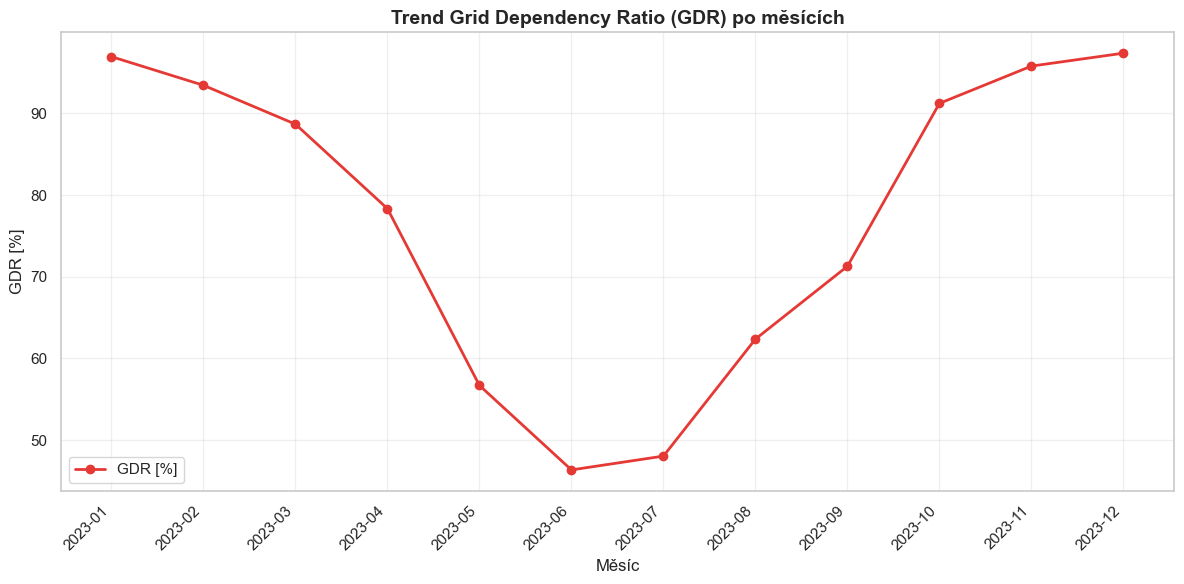

In [40]:
# === Graf 1: Trend GDR po měsících ===
# GDR = 1 - (solarni_vyroba / spotreba) — čím nižší, tím méně závislý na síti

# Agregace přes DuckDB SQL — výpočet GDR po měsících
df_gdr = con.execute("""
    SELECT
        EXTRACT(YEAR FROM timestamp) AS rok,                         -- extrakce roku
        EXTRACT(MONTH FROM timestamp) AS mesic,                      -- extrakce měsíce
        1 - (SUM(solarni_vyroba) / SUM(spotreba)) AS gdr            -- výpočet GDR za měsíc
    FROM v_net_load
    WHERE spotreba > 0                                                -- vyloučíme nulovou spotřebu (dělení nulou)
    GROUP BY rok, mesic                                               -- seskupení po měsících
    ORDER BY rok, mesic                                               -- chronologické řazení
""").df()  # výsledek jako Pandas DataFrame

# Vytvoření popisku osy X ve formátu "YYYY-MM"
df_gdr["obdobi"] = df_gdr["rok"].astype(int).astype(str) + "-" + df_gdr["mesic"].astype(int).astype(str).str.zfill(2)

# Vykreslení grafu
fig, ax = plt.subplots(figsize=(12, 6))  # vytvoření figury a os
ax.plot(df_gdr["obdobi"], df_gdr["gdr"] * 100, marker="o", linewidth=2, color="#E53935", label="GDR [%]")  # čára s body
ax.set_title("Trend Grid Dependency Ratio (GDR) po měsících", fontsize=14, fontweight="bold")  # titulek
ax.set_xlabel("Měsíc", fontsize=12)         # popisek osy X
ax.set_ylabel("GDR [%]", fontsize=12)        # popisek osy Y s jednotkou
ax.legend(fontsize=11)                        # legenda
ax.grid(True, alpha=0.3)                      # mřížka pro lepší čitelnost
plt.xticks(rotation=45, ha="right")           # natočení popisků osy X pro čitelnost
plt.tight_layout()                             # automatická úprava okrajů
plt.savefig("output/graf_01_gdr_trend.png", dpi=150, bbox_inches="tight")  # uložení jako PNG
plt.show()                                     # zobrazení grafu

# Interpretace: Pokud GDR klesá v létě, potvrzuje to vyšší solární pokrytí.
# V zimě očekáváme GDR blíže k 100 % (nízká solární výroba).

### 7.2 Graf 2 — Korelace oblačnosti a solární výroby (Scatter plot)

**KPI:** GDR (nepřímo — oblačnost ovlivňuje solární výrobu, a tedy i GDR)  
**Otázka:** Existuje jasný negativní vztah mezi oblačností a solární výrobou?  
**Očekávání:** Vyšší oblačnost → nižší solární výroba.

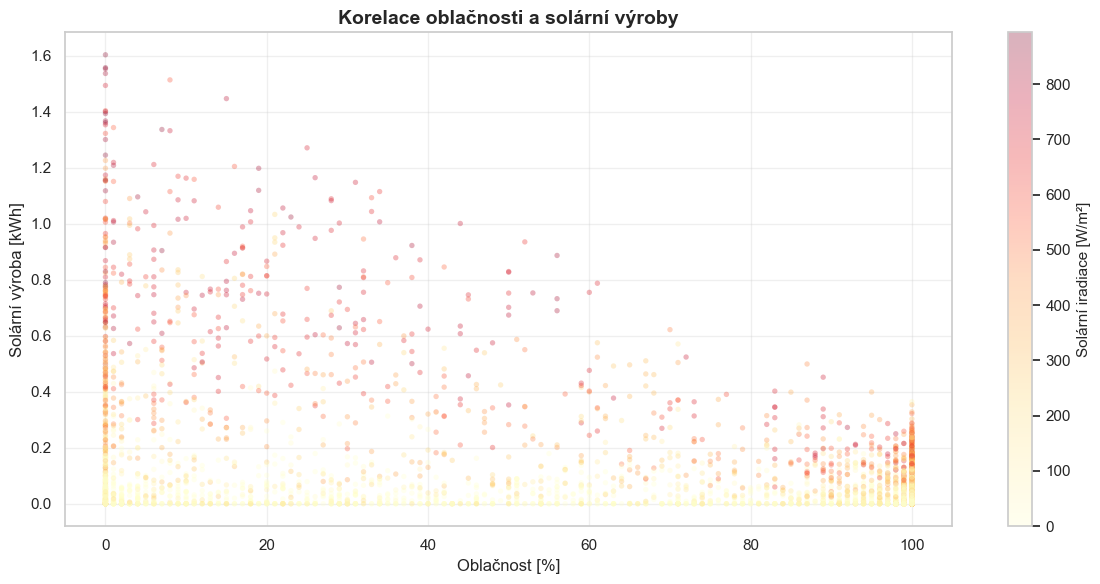

Pearsonova korelace (oblačnost vs. solární výroba): -0.389


In [41]:
# === Graf 2: Scatter plot — oblačnost vs. solární výroba ===

# Vzorek dat pro scatter plot (plný dataset může být příliš hustý)
df_sample = df.dropna(subset=["oblacnost", "solarni_vyroba"]).sample(  # odstranění NaN a náhodný výběr
    n=min(5000, len(df)),  # max 5000 bodů pro čitelnost
    random_state=42         # fixní seed pro reprodukovatelnost
)

fig, ax = plt.subplots(figsize=(12, 6))  # vytvoření figury
scatter = ax.scatter(
    df_sample["oblacnost"],        # osa X — oblačnost
    df_sample["solarni_vyroba"],   # osa Y — solární výroba
    alpha=0.3,                      # průhlednost bodů (překrývání)
    s=15,                           # velikost bodů
    c=df_sample["solarni_iradiace"],  # barva dle iradiace — přidává třetí dimenzi
    cmap="YlOrRd",                 # barevná škála žlutá → červená
    edgecolors="none"              # bez okrajů bodů
)
cbar = plt.colorbar(scatter, ax=ax)             # barevná škála jako legenda
cbar.set_label("Solární iradiace [W/m²]", fontsize=11)  # popisek škály
ax.set_title("Korelace oblačnosti a solární výroby", fontsize=14, fontweight="bold")  # titulek
ax.set_xlabel("Oblačnost [%]", fontsize=12)     # osa X s jednotkou
ax.set_ylabel("Solární výroba [kWh]", fontsize=12)  # osa Y s jednotkou
ax.grid(True, alpha=0.3)                         # mřížka
plt.tight_layout()                                # úprava okrajů
plt.savefig("output/graf_02_oblacnost_solar.png", dpi=150, bbox_inches="tight")  # uložení PNG
plt.show()                                        # zobrazení

# Korelační koeficient
corr = df[["oblacnost", "solarni_vyroba"]].corr().iloc[0, 1]  # Pearsonova korelace
print(f"Pearsonova korelace (oblačnost vs. solární výroba): {corr:.3f}")
# Interpretace: Záporná korelace potvrzuje očekávaný vztah. Sílu vztahu posuzujeme opatrně.

### 7.3 Graf 3 — Průměrný Net Load podle hodin / Kachní křivka (Bar chart)

**KPI:** PLC (Peak Load Cost) — špička 18:00–21:00  
**Otázka:** Jak vypadá denní profil net load? Potvrdí data existenci tzv. kachní křivky (duck curve)?  
**Očekávání:** Přes den nízký/záporný net load (solární výroba), večer prudký nárůst.

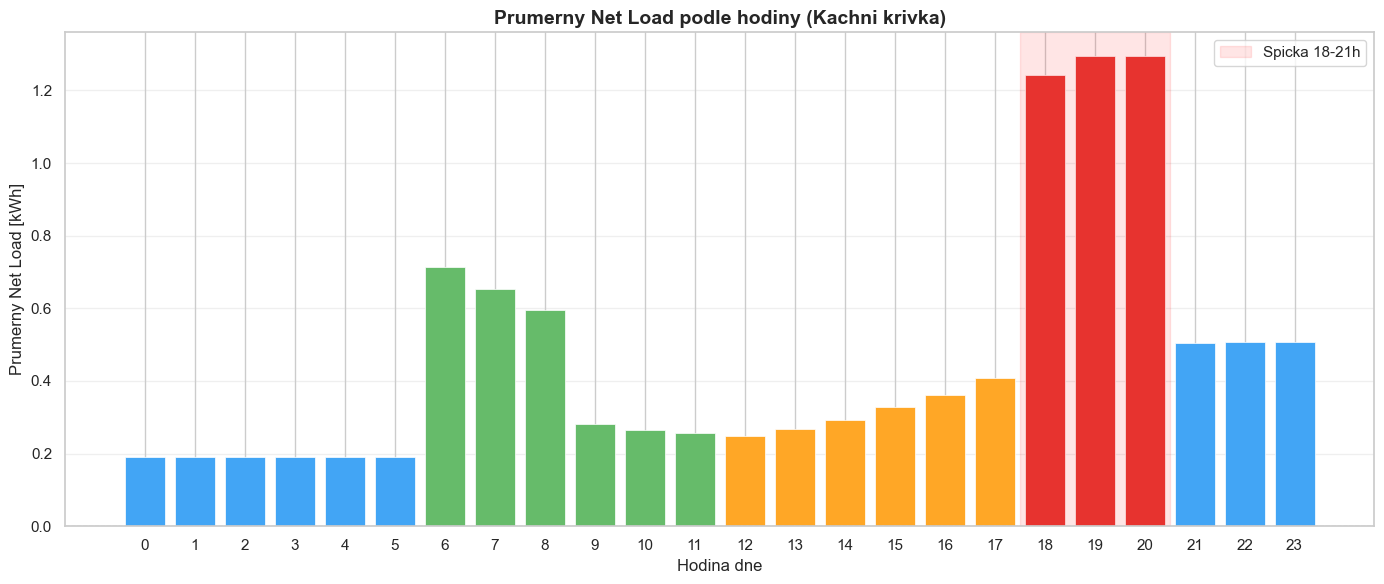

In [42]:
# === Graf 3: Bar chart ===

# Prumerny net load podle hodiny
hourly_avg = df.groupby("hodina")["net_load"].mean()

# Barvy podle segmentu
colors = []
for h in range(24):
    if 18 <= h < 21:   colors.append("#E53935")  # cervena pro spicku
    elif 12 <= h < 18: colors.append("#FFA726")   # oranzova pro odpoledne
    elif 6 <= h < 12:  colors.append("#66BB6A")   # zelena pro rano
    else:              colors.append("#42A5F5")    # modra pro noc

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(hourly_avg.index, hourly_avg.values, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.axvspan(17.5, 20.5, alpha=0.1, color="red", label="Spicka 18-21h")
ax.set_title("Prumerny Net Load podle hodiny (Kachni krivka)", fontsize=14, fontweight="bold")
ax.set_xlabel("Hodina dne", fontsize=12)
ax.set_ylabel("Prumerny Net Load [kWh]", fontsize=12)
ax.set_xticks(range(24))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("output/graf_03_kachni_krivka.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Graf 4 — Distribuce Peak Load Cost (Histogram)

**KPI:** PLC (Peak Load Cost)  
**Otázka:** Jak je rozložen denní náklad za spotřebu ve špičce 18:00–21:00?  
**Předpoklad:** Simulovaná cena 5 CZK/kWh za špičkovou elektřinu.

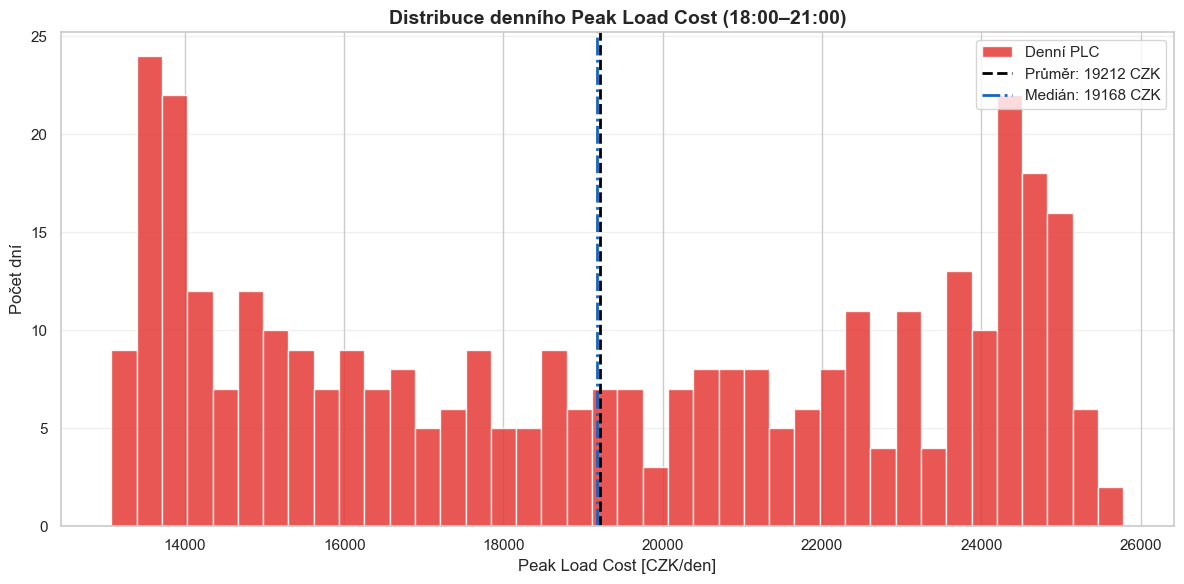

Statistika PLC [CZK/den]: min=13078, max=25783, průměr=19212, medián=19168


In [43]:
# === Graf 4: Histogram — distribuce Peak Load Cost ===

CENA_KWH_SPICKA = 5.0  # simulovaná cena za kWh ve špičce [CZK]

# Filtrování pouze špičkových hodin (18:00–20:59)
df_peak = df[df["hodina"].between(18, 20)].copy()  # .copy() zabraňuje SettingWithCopyWarning

# Výpočet denního PLC — součet spotřeby za špičku * cena, seskupeno po dnech
df_peak["datum"] = df_peak["timestamp"].dt.date  # extrakce data (bez času)
plc_daily = df_peak.groupby("datum")["spotreba"].sum() * CENA_KWH_SPICKA  # denní PLC v CZK

fig, ax = plt.subplots(figsize=(12, 6))  # vytvoření figury
ax.hist(plc_daily, bins=40, color="#E53935", edgecolor="white", alpha=0.85, label="Denní PLC")  # histogram
ax.axvline(plc_daily.mean(), color="black", linestyle="--", linewidth=2, label=f"Průměr: {plc_daily.mean():.0f} CZK")  # průměr
ax.axvline(plc_daily.median(), color="#1565C0", linestyle="-.", linewidth=2, label=f"Medián: {plc_daily.median():.0f} CZK")  # medián
ax.set_title("Distribuce denního Peak Load Cost (18:00–21:00)", fontsize=14, fontweight="bold")  # titulek
ax.set_xlabel("Peak Load Cost [CZK/den]", fontsize=12)  # osa X s jednotkou
ax.set_ylabel("Počet dní", fontsize=12)                   # osa Y
ax.legend(fontsize=11)                                     # legenda
ax.grid(True, alpha=0.3, axis="y")                         # vodorovná mřížka
plt.tight_layout()                                          # úprava okrajů
plt.savefig("output/graf_04_plc_distribuce.png", dpi=150, bbox_inches="tight")  # uložení
plt.show()                                                  # zobrazení

print(f"Statistika PLC [CZK/den]: min={plc_daily.min():.0f}, max={plc_daily.max():.0f}, "
      f"průměr={plc_daily.mean():.0f}, medián={plc_daily.median():.0f}")

### 7.5 Graf 5 — Detekce outlierů ve spotřebě (Box-plot)

**KPI:** DQS (Data Quality Score)  
**Otázka:** Jak velký šum obsahují senzorová data? Jsou outliery koncentrovány v určité denní době?  
**Kontext:** Data ze smart meterů obsahují záměrně zanesený šum simulující reálné senzorové chyby.

UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

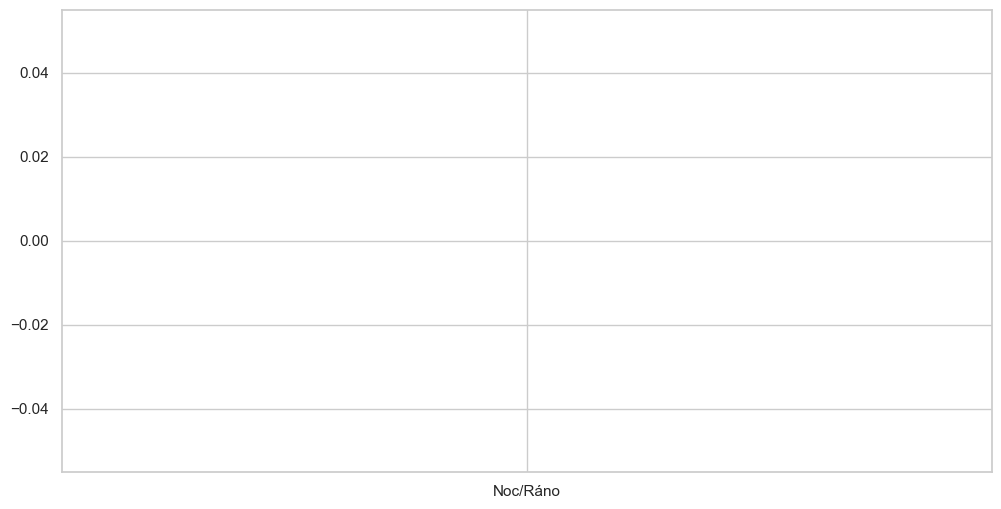

In [44]:
# === Graf 5: Box-plot — outliery ve spotřebě podle denní doby ===

fig, ax = plt.subplots(figsize=(12, 6))  # vytvoření figury

# Seřazení segmentů pro logické pořadí na ose X
segment_order = ["Noc/Ráno", "Ráno (6–12)", "Odpoledne (12–18)", "Špička (18–21)"]  # požadované pořadí

sns.boxplot(
    data=df,                       # zdrojová data
    x="segment",                   # osa X — segment denní doby
    y="spotreba",                  # osa Y — spotřeba v kWh
    order=segment_order,           # řazení kategorií
    palette="Set2",                # barevná paleta
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},  # styl outlierů (malé průhledné body)
    ax=ax                          # vykreslení do připravených os
)
ax.set_title("Distribuce spotřeby podle denní doby (detekce outlierů)", fontsize=14, fontweight="bold")  # titulek
ax.set_xlabel("Segment dne", fontsize=12)          # osa X
ax.set_ylabel("Spotřeba [kWh]", fontsize=12)       # osa Y s jednotkou
ax.grid(True, alpha=0.3, axis="y")                  # vodorovná mřížka
plt.tight_layout()                                   # úprava okrajů
plt.savefig("output/graf_05_outliery_spotreba.png", dpi=150, bbox_inches="tight")  # uložení
plt.show()                                           # zobrazení

# Interpretace: Body za vousy box-plotu = outliery.
# Vysoký počet outlierů indikuje šum ze senzorů — snižuje DQS.

### 7.6 Graf 6 — Vývoj Data Quality Score v čase (Line chart)

**KPI:** DQS (Data Quality Score)  
**Otázka:** Mění se kvalita senzorových dat v čase? Existují období s vyšším počtem výpadků?  
**Definice:** DQS = podíl platných záznamů (bez NaN a bez outlierů) z celkového počtu.

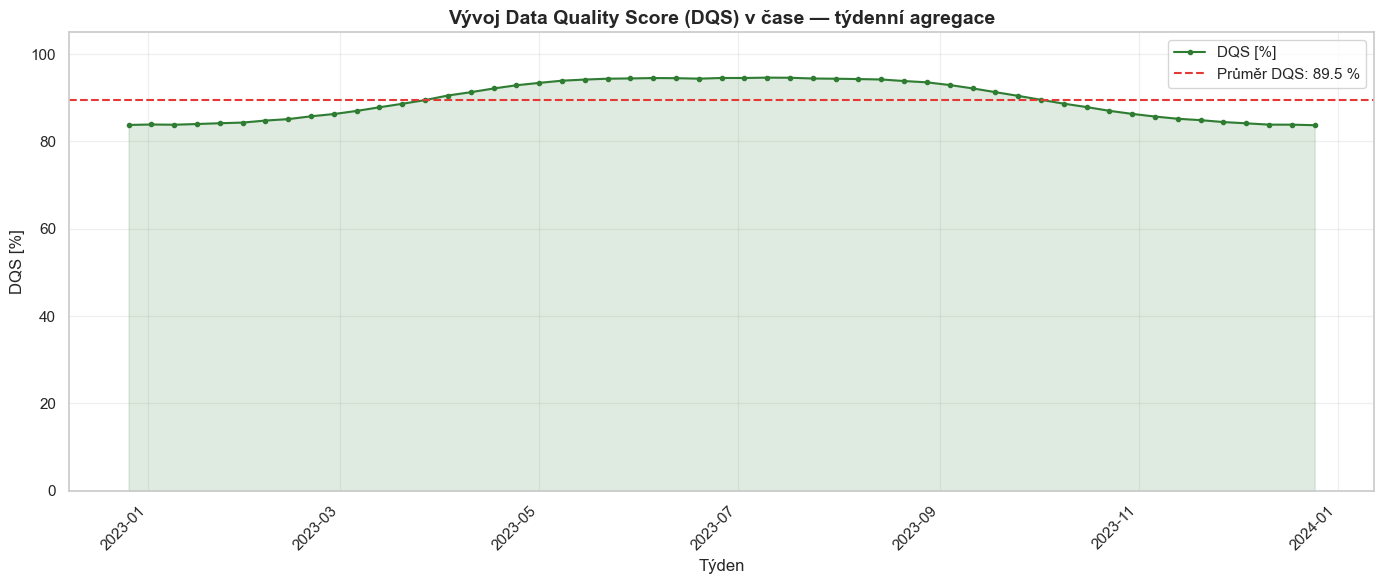

In [ ]:
# === Graf 6: Line chart ===

# Tydenni agregace DQS (is_valid a tyden jiz existuji z Feature Engineering)
dqs_weekly = df.groupby("tyden")["is_valid"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(dqs_weekly.index, dqs_weekly.values, marker=".", linewidth=1.5, color="#2E7D32", label="DQS [%]")
ax.axhline(y=dqs_weekly.mean(), color="#E53935", linestyle="--", linewidth=1.5,
           label=f"Prumer DQS: {dqs_weekly.mean():.1f} %")
ax.fill_between(dqs_weekly.index, dqs_weekly.values, alpha=0.15, color="#2E7D32")
ax.set_title("Vyvoj Data Quality Score (DQS) v case", fontsize=14, fontweight="bold")
ax.set_xlabel("Tyden", fontsize=12)
ax.set_ylabel("DQS [%]", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("output/graf_06_dqs_vyvoj.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Závěry a vazba na KPI

> **Účel:** Shrnout nejdůležitější zjištění z EDA a navázat je na KPI projektu.

### Hlavní zjištění

| # | Zjištění | Napojení na KPI | Typ |
|---|---------|-----------------|-----|
| 1 | GDR vykazuje sezónní vzorec — nižší v létě (vyšší solární výroba), vyšší v zimě | GDR | Podložené zjištění |
| 2 | Oblačnost negativně koreluje se solární výrobou — potvrzuje fyzikální očekávání | GDR (nepřímo) | Podložené zjištění |
| 3 | Denní profil net load vykazuje tvar kachní křivky — špička mezi 18–21h | PLC | Podložené zjištění |
| 4 | Distribuce PLC ukazuje variabilitu denních nákladů ve špičce | PLC | Podložené zjištění |
| 5 | Senzorová data obsahují outliery odpovídající záměrně zanesenému šumu | DQS | Podložené zjištění |
| 6 | DQS kolísá v čase — existují období s nižší kvalitou dat | DQS | Pozorování (nutná hlubší analýza) |

### Limity analýzy

- **Syntetická data:** Smart meter data jsou generovaná — závěry nelze přímo přenést na reálné prostředí.
- **Zjednodušený model PLC:** Použitá fixní cena 5 CZK/kWh neodráží reálnou tarifní strukturu.
- **INNER JOIN:** Záznamy bez shody v timestamp byly vyloučeny — potenciální ztráta dat.
- **IQR metoda outlierů:** Jednoduchá heuristika — některé legitimní hodnoty mohly být označeny jako outliery.

### Další kroky

1. Vizualizace KPI v Tableau dashboardu pro interaktivní průzkum.
2. Hlubší segmentace GDR podle typu domácnosti (pokud data budou rozšířena).
3. Analýza dopadu reálné tarifní struktury na PLC.
4. Nastavení alertů pro pokles DQS pod definovaný práh.

In [ ]:
# === Uzavření spojení s DuckDB ===

con.close()  # ukončení databázového spojení — uvolní zamčený soubor
print("Spojení s DuckDB uzavřeno.")
print("EDA dokončena. Grafy uloženy v složce output/.")

Spojení s DuckDB uzavřeno.
EDA dokončena. Grafy uloženy v složce output/.
